# NER: reconocer entidades con BERT

Una noticia completa ya no recibe una sola etiqueta: asignamos etiquetas a sus palabras para localizar
**personas (PER), organizaciones (ORG), lugares (LOC) y otras entidades (MISC)**.

| Palabra | Etiqueta | Interpretación |
|---|---|---|
| John | B-PER | Comienza una persona |
| Smith | I-PER | Continúa esa persona |
| visited | O | Fuera de una entidad |
| New | B-LOC | Comienza un lugar |
| York | I-LOC | Continúa ese lugar |

**Hipótesis:** ajustar todo BERT podría mejorar la detección frente a entrenar solo sus dos últimas capas;
mediremos si la diferencia justifica el costo. El ganador no está fijado de antemano.

## 1. Preparar el entorno
Usamos el entorno de AG News más `seqeval==1.2.2`. El repositorio completo debe estar disponible,
incluidos `src/ner_experiment.py` y `src/agnews_experiment.py` (utilidades compartidas).
Consulta `NER_GUIDE.md` para instalación local o en Colab.

In [1]:
from pathlib import Path
import sys, os, json
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "ner_experiment.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Abre el notebook dentro del repositorio completo")
sys.path.insert(0, str(ROOT / "src"))
print("Proyecto:", ROOT)
print("Python:", sys.executable)
# En un entorno nuevo, instalar una vez y reiniciar el kernel:
# %pip install -r {ROOT / "requirements-ner.txt"}

Proyecto: C:\Users\IGNITER\Downloads\bert-adaptation
Python: C:\Users\IGNITER\Documents\ChatGPT\Cosas Escuela 2\.venv-agnews\Scripts\python.exe


## 2. Configuración
- BERT-base-cased conserva mayúsculas, una señal útil para nombres propios.
- CoNLL-2003: particiones oficiales train/validation/test. Se auditan coincidencias textuales entre ellas.
- Ajuste parcial: cabeza + últimas dos capas. Ajuste completo: todos los parámetros.
- Tres épocas, semilla 42, batch efectivo 16, LR cabeza 1e-3 y encoder 2e-5.
- Sin truncar frases; padding dinámico. Solo la primera subpalabra recibe la etiqueta de su palabra.

`SMOKE=True` ejecuta 32/16/16 frases, una época. Sirve para comprobar el código; sus métricas no son entregables.

In [2]:
from datetime import datetime
from dataclasses import asdict
from ner_experiment import Config, run_experiment
import torch
SMOKE = os.environ.get("NER_SMOKE", "0") == "1"
cfg = Config(smoke=SMOKE, epochs=1 if SMOKE else 3)
RUN = ROOT / "runs" / (os.environ.get("NER_RUN_NAME") or
                       (("ner_smoke_" if SMOKE else "ner_") + datetime.now().strftime("%Y%m%d_%H%M%S")))
print(asdict(cfg))
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Salida:", RUN)

C:\Users\IGNITER\Documents\ChatGPT\Cosas Escuela 2\.venv-agnews\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'seed': 42, 'epochs': 1, 'micro_batch': 8, 'accumulation': 2, 'top_layers': 2, 'head_lr': 0.001, 'backbone_lr': 2e-05, 'weight_decay': 0.01, 'model_id': 'google-bert/bert-base-cased', 'dataset_id': 'lhoestq/conll2003', 'model_revision': None, 'dataset_revision': None, 'smoke': True}
GPU: NVIDIA GeForce RTX 4060 Ti
Salida: C:\Users\IGNITER\Downloads\bert-adaptation\runs\ner_smoke_verified_v2


## 3. Alinear, entrenar y elegir
Antes del entrenamiento, la siguiente celda imprime un batch de subtokens y etiquetas.
Se comprueba que cada palabra tenga exactamente una etiqueta y que especiales, continuaciones y padding tengan `-100`.
La auditoría completa queda en `alignment_check.csv`.

La pérdida se promedia por palabras supervisadas. La **métrica principal** es F1 micro de entidades en modo estricto IOB2:
tipo y límites completos deben coincidir. Detectar solo “New” no acierta la entidad “New York”.
Accuracy por palabra es secundaria: acertar muchas `O` no demuestra que se detecten bien las entidades.

Se guarda la mejor época por validación de cada alternativa y después se selecciona el método.
Solo entonces se evalúa test. La parte congelada mantiene dropout desactivado y se verifican sus pesos por hash.

In [3]:
comparison = run_experiment(cfg, RUN)
display(comparison)

 batch_row  source_row  position    subtoken         word  label_id  label
         0        1204         0       [CLS]                   -100 IGNORE
         0        1204         1           J JOHANNESBURG         5  B-LOC
         0        1204         2        ##OH JOHANNESBURG      -100 IGNORE
         0        1204         3        ##AN JOHANNESBURG      -100 IGNORE
         0        1204         4        ##NE JOHANNESBURG      -100 IGNORE
         0        1204         5        ##SB JOHANNESBURG      -100 IGNORE
         0        1204         6        ##UR JOHANNESBURG      -100 IGNORE
         0        1204         7         ##G JOHANNESBURG      -100 IGNORE
         0        1204         8        1996   1996-08-22         0      O
         0        1204         9           -   1996-08-22      -100 IGNORE
         0        1204        10          08   1996-08-22      -100 IGNORE
         0        1204        11           -   1996-08-22      -100 IGNORE
         0        1204   

Data audit: {"split_sizes": {"train": 32, "validation": 16, "test": 16}, "max_subtoken_lengths": {"train": 58, "validation": 53, "test": 37}, "cross_split_exact_sentence_overlaps": {"train/validation": 0, "train/test": 0, "validation/test": 0}}


Some weights of BertForTokenClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


partial_finetuning {"epoch": 1, "train_loss": 2.1666819693995456, "train_seconds": 0.38947329999064095, "validation_seconds": 0.04511799997999333, "val_loss": 1.926510578369204, "val_precision": 0.0, "val_recall": 0.0, "val_f1": 0.0, "val_token_accuracy": 0.4730290456431535, "val_conlleval_f1": 0.019230769230769232, "val_invalid_predicted_i_transitions": 71}


Some weights of BertForTokenClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


full_finetuning {"epoch": 1, "train_loss": 2.1228707154591877, "train_seconds": 0.36608229999546893, "validation_seconds": 0.032960399985313416, "val_loss": 1.8010081824425346, "val_precision": 0.0, "val_recall": 0.0, "val_f1": 0.0, "val_token_accuracy": 0.6804979253112033, "val_conlleval_f1": 0.0, "val_invalid_predicted_i_transitions": 40}


COMPLETE: C:\Users\IGNITER\Downloads\bert-adaptation\runs\ner_smoke_verified_v2 winner: partial_finetuning


,method,best_epoch,best_val_f1,trainable_parameters,total_parameters,frozen_parameters_verified,train_seconds,peak_allocated_gpu_bytes,test_loss,test_precision,test_recall,test_f1,test_token_accuracy,test_conlleval_f1,test_invalid_predicted_i_transitions,selected
0,partial_finetuning,1,0.0,14182665,107726601,True,0.389473,755843072,1.969195,0.0,0.0,0.0,0.333333,0.0,44,True
1,full_finetuning,1,0.0,107726601,107726601,False,0.366082,2264827904,1.854484,0.0,0.0,0.0,0.536585,0.0,26,False


## 4. Interpretar las curvas
Precisión: de las entidades predichas, cuántas fueron correctas.
Recall: de las entidades reales, cuántas encontramos. F1 combina ambas.
Una sola semilla no permite afirmar significancia estadística: diferencias pequeñas pueden depender del azar.

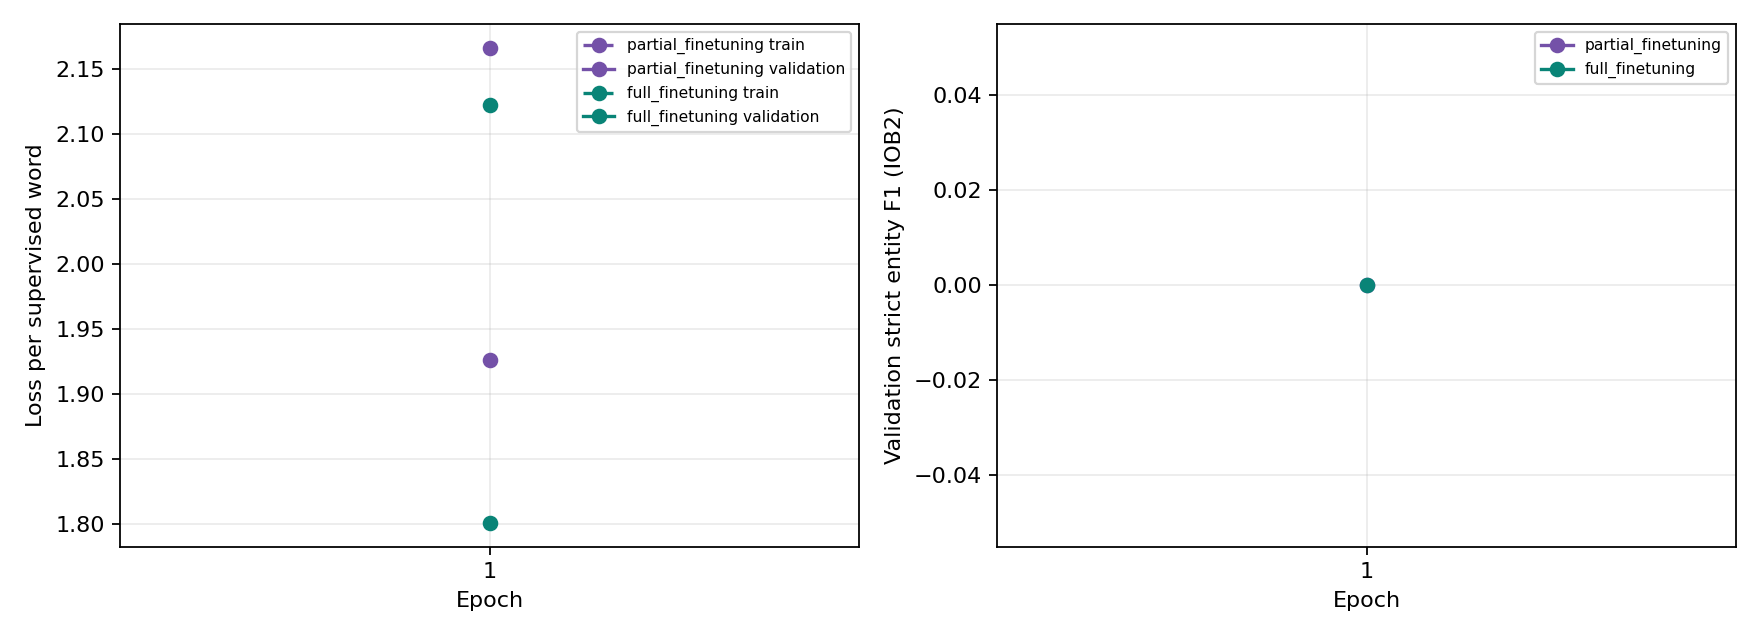

# NER: resultados medidos

PRUEBA TECNICA: no son resultados finales.

Particiones oficiales: {'train': 32, 'validation': 16, 'test': 16}. Sin truncamiento; máximos de subtokens: {'train': 58, 'validation': 53, 'test': 37}.
Frases exactas compartidas entre particiones (conservadas para mantener el benchmark): {'train/validation': 0, 'train/test': 0, 'validation/test': 0}.
Selección: F1 micro de entidades, seqeval strict IOB2. La entidad debe coincidir en tipo, inicio y fin.

| Método | Época | F1 validación | Precisión prueba | Recall prueba | F1 prueba | Entrenamiento (s) |
|---|---:|---:|---:|---:|---:|---:|
| partial_finetuning | 1 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.4 |
| full_finetuning | 1 | 0.0000 | 0.0000 | 0.0000 | 0.0000 | 0.4 |

Ganador por validación: **partial_finetuning**. Prueba se evaluó después de guardar la selección.
Los tiempos excluyen validación y guardado; ambos métodos ejecutan el cuerpo de BERT en cada lote.
La pérdida se promedia por palabras supervisadas, no por frases ni subtokens ignorados.
Una semilla no establece superioridad estadística; diferencias pequeñas pueden depender del azar.
No se ajustaron hiperparámetros con prueba. Las etiquetas O no dominan la métrica principal de entidades.

## Errores: partial_finetuning

```json
{
  "gold_entities": 22,
  "predicted_entities": 2,
  "correct_entities": 0,
  "false_positive_entities": 2,
  "missed_entity": 21,
  "overlapping_wrong_boundary": 1
}
```

Tipos incorrectos, límites incorrectos y entidades omitidas son categorías excluyentes de errores sobre entidades reales. Falsos positivos se cuentan aparte.

## Errores: full_finetuning

```json
{
  "gold_entities": 22,
  "predicted_entities": 1,
  "correct_entities": 0,
  "false_positive_entities": 1,
  "missed_entity": 22
}
```

Tipos incorrectos, límites incorrectos y entidades omitidas son categorías excluyentes de errores sobre entidades reales. Falsos positivos se cuentan aparte.

Evidencia: data_manifest.json, alignment_check.csv, historiales, selection.json, predicciones por palabra, métricas por tipo y ejemplos de error.
BERT-base-cased, precisión bf16 cuando la GPU lo admite, semilla 42 y dos grupos de LR (cabeza 1e-3, encoder 2e-5).
Fuentes: https://huggingface.co/datasets/lhoestq/conll2003 ; https://github.com/chakki-works/seqeval ; https://arxiv.org/abs/1810.04805
POS y QA siguen pendientes. El reporte PDF anterior aún no fue actualizado. Modelo exportado localmente, no publicado.


Ejemplo del batch de alineación:


,batch_row,source_row,position,subtoken,word,label_id,label
0,0,1204,0,[CLS],NaN,-100,IGNORE
1,0,1204,1,J,JOHANNESBURG,5,B-LOC
2,0,1204,2,##OH,JOHANNESBURG,-100,IGNORE
3,0,1204,3,##AN,JOHANNESBURG,-100,IGNORE
4,0,1204,4,##NE,JOHANNESBURG,-100,IGNORE
5,0,1204,5,##SB,JOHANNESBURG,-100,IGNORE
6,0,1204,6,##UR,JOHANNESBURG,-100,IGNORE
7,0,1204,7,##G,JOHANNESBURG,-100,IGNORE
8,0,1204,8,1996,1996-08-22,0,O
9,0,1204,9,-,1996-08-22,-100,IGNORE


In [4]:
import pandas as pd
from IPython.display import Image, Markdown, display
display(Image(filename=str(RUN / "learning_curves.png")))
display(Markdown((RUN / "RESULTS.md").read_text(encoding="utf-8")))
print("Ejemplo del batch de alineación:")
display(pd.read_csv(RUN / "alignment_check.csv").head(35))

## 5. Entender errores concretos
Revisamos tipos incorrectos, límites incorrectos y entidades omitidas. Los falsos positivos se cuentan aparte.
Estas observaciones describen el resultado final; no usamos test para retocar el entrenamiento.
`per_type` muestra si un tipo de entidad presenta más dificultad que otros.

In [5]:
for method in comparison.method:
    print(method)
    scores = json.loads((RUN / method / "test_metrics.json").read_text(encoding="utf-8"))
    display(pd.DataFrame(scores["per_type"]).T)
    errors = json.loads((RUN / method / "error_analysis.json").read_text(encoding="utf-8"))
    print(errors["counts"])
    display(pd.DataFrame(errors["examples"][:5]))

partial_finetuning


,precision,recall,f1-score,support
LOC,0.0,0.0,0.0,9.0
MISC,0.0,0.0,0.0,5.0
ORG,0.0,0.0,0.0,3.0
PER,0.0,0.0,0.0,5.0
micro avg,0.0,0.0,0.0,22.0
macro avg,0.0,0.0,0.0,22.0
weighted avg,0.0,0.0,0.0,22.0


{'gold_entities': 22, 'predicted_entities': 2, 'correct_entities': 0, 'false_positive_entities': 2, 'missed_entity': 21, 'overlapping_wrong_boundary': 1}


,source_row,text,missed_or_wrong,extra_or_wrong
0,306,"On several occasions during his innings , the ...",[],"[{'type': 'PER', 'start_word': 12, 'end_word_e..."
1,2538,6. Miriam Vogt ( Germany ) 1:49.28,"[{'type': 'LOC', 'start_word': 4, 'end_word_ex...",[]
2,2402,5. Isolde Kostner ( Italy ) 1:18.19,"[{'type': 'LOC', 'start_word': 4, 'end_word_ex...",[]
3,2251,-- Canberra Bureau 61-6 273-2730,"[{'type': 'LOC', 'start_word': 1, 'end_word_ex...",[]
4,1815,The five breeds credited with the most inciden...,"[{'type': 'MISC', 'start_word': 12, 'end_word_...","[{'type': 'LOC', 'start_word': 18, 'end_word_e..."


full_finetuning


,precision,recall,f1-score,support
LOC,0.0,0.0,0.0,9.0
MISC,0.0,0.0,0.0,5.0
ORG,0.0,0.0,0.0,3.0
PER,0.0,0.0,0.0,5.0
micro avg,0.0,0.0,0.0,22.0
macro avg,0.0,0.0,0.0,22.0
weighted avg,0.0,0.0,0.0,22.0


{'gold_entities': 22, 'predicted_entities': 1, 'correct_entities': 0, 'false_positive_entities': 1, 'missed_entity': 22}


,source_row,text,missed_or_wrong,extra_or_wrong
0,2538,6. Miriam Vogt ( Germany ) 1:49.28,"[{'type': 'LOC', 'start_word': 4, 'end_word_ex...",[]
1,2402,5. Isolde Kostner ( Italy ) 1:18.19,"[{'type': 'LOC', 'start_word': 4, 'end_word_ex...",[]
2,2251,-- Canberra Bureau 61-6 273-2730,"[{'type': 'LOC', 'start_word': 1, 'end_word_ex...",[]
3,1815,The five breeds credited with the most inciden...,"[{'type': 'MISC', 'start_word': 12, 'end_word_...","[{'type': 'MISC', 'start_word': 7, 'end_word_e..."
4,2626,"7. Czech Republic I ( Jiri Dzmura , Pavel Polo...","[{'type': 'ORG', 'start_word': 1, 'end_word_ex...",[]


## 6. Probar el modelo exportado
La ejecución final exporta y recarga el ganador, con su tokenizer y model card.
La inferencia conserva la misma regla de primera subpalabra usada en la evaluación.
Este ejemplo comprueba funcionamiento; no reemplaza las métricas de prueba.
La publicación en Hugging Face queda para la etapa de publicación.

In [6]:
if not SMOKE:
    example = json.loads((RUN / "inference_example.json").read_text(encoding="utf-8"))
    display(pd.DataFrame({"palabra": example["words"], "etiqueta": example["tags"]}))
    print("Modelo:", RUN / "delivered_model_ner")
else:
    print("Smoke completado. Falta la ejecución completa para obtener resultados entregables.")

Smoke completado. Falta la ejecución completa para obtener resultados entregables.
